# Analisis Lanjutan Random Forest - Validasi Akademik

**Project:** Prediksi Polusi PM2.5 di Jakarta Berdasarkan Faktor Cuaca Menggunakan Random Forest Regression

**Scope:** notebook ini menambahkan 5 analisis pelengkap untuk memperkuat justifikasi akademik:
1. **Learning Curve** - apakah model akan membaik dengan lebih banyak data?
2. **Permutation Importance** - feature importance yang lebih reliable (model-agnostic)
3. **SHAP Analysis** - explainability tingkat individual prediksi
4. **PR / ROC Curve** - performa klasifikasi kategori "Tidak Sehat" (PM2.5 > 100)
5. **Error Temporal per Stasiun** - distribusi error sepanjang periode test

Semua analisis pakai dataset v1 (`dataset_final_model.csv`) dan model RF terbaik (Grid Search) - sesuai scope proposal.

## 0. Install Dependency (jalankan sekali)

Notebook ini butuh `shap`. Cell di bawah akan auto-install jika belum ada di environment kernel.

In [1]:
# Auto-install shap jika belum ada (pakai magic %pip supaya pasti install ke env kernel)
try:
    import shap
    print(f'shap {shap.__version__} sudah terpasang')
except ImportError:
    %pip install -q shap
    import shap
    print(f'shap {shap.__version__} terpasang')


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


shap 0.52.0 terpasang


## 1. Setup, Import, & Load Model RF Terbaik

In [2]:
import json, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
from pathlib import Path
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             precision_recall_curve, roc_curve, auc, average_precision_score)

import shap

RANDOM = 42
np.random.seed(RANDOM)
DIR_OUT = Path('outputs')
PATH_DATA = Path('../data/final for modelling/dataset_final_model.csv')
TARGET = 'ISPU PM2.5'
print('Imports OK')

Imports OK


## 2. Reload Data + Re-build Fitur (sama dengan 02_Modelling.ipynb section perbaikan)

In [3]:
df = pd.read_csv(PATH_DATA)
df['tanggal'] = pd.to_datetime(df['tanggal'])
kolom_stasiun = [c for c in df.columns if c.startswith('station_')]
df['station'] = df[kolom_stasiun].idxmax(axis=1).str.replace('station_', '', regex=False)

# Cyclical time
df['bulan_sin'] = np.sin(2 * np.pi * df['bulan'] / 12)
df['bulan_cos'] = np.cos(2 * np.pi * df['bulan'] / 12)
df['hari_minggu_sin'] = np.sin(2 * np.pi * df['hari_minggu'] / 7)
df['hari_minggu_cos'] = np.cos(2 * np.pi * df['hari_minggu'] / 7)

# Musim Jakarta
def musim(b):
    if b in (11, 12, 1, 2, 3): return 'Hujan'
    if b == 4: return 'Transisi'
    return 'Kemarau'
df['musim'] = df['bulan'].map(musim)

# Lag & rolling per station
for lag in [1, 3, 7]:
    df[f'pm25_lag_{lag}'] = df.groupby('station')[TARGET].shift(lag)
prev = df.groupby('station')[TARGET].shift(1)
def rs(s, w, f):
    return s.groupby(df['station']).rolling(w).agg(f).reset_index(level=0, drop=True)
df['pm25_rolling_mean_3'] = rs(prev, 3, 'mean')
df['pm25_rolling_mean_7'] = rs(prev, 7, 'mean')
df['pm25_rolling_max_7']  = rs(prev, 7, 'max')
df['pm25_rolling_std_7']  = rs(prev, 7, 'std')

fitur_lag = ['pm25_lag_1', 'pm25_lag_3', 'pm25_lag_7',
             'pm25_rolling_mean_3', 'pm25_rolling_mean_7', 'pm25_rolling_max_7', 'pm25_rolling_std_7']
df = df.dropna(subset=fitur_lag + [TARGET]).reset_index(drop=True)

KOLOM_NUMERIK = (['temp', 'humidity', 'visibility', 'windgust', 'solarenergy', 'precip']
                 + fitur_lag
                 + ['bulan_sin', 'bulan_cos', 'hari_minggu_sin', 'hari_minggu_cos']
                 + kolom_stasiun)
DAFTAR_FITUR = KOLOM_NUMERIK + ['musim']

# Time split 70/15/15
ud = np.array(sorted(df['tanggal'].unique()))
n = len(ud)
b1 = pd.Timestamp(ud[int(n * 0.70)])
b2 = pd.Timestamp(ud[int(n * 0.85)])
m_tr = df['tanggal'] < b1
m_va = (df['tanggal'] >= b1) & (df['tanggal'] < b2)
m_te = df['tanggal'] >= b2

X_tr = df.loc[m_tr, DAFTAR_FITUR].copy()
X_va = df.loc[m_va, DAFTAR_FITUR].copy()
X_te = df.loc[m_te, DAFTAR_FITUR].copy()
y_tr = df.loc[m_tr, TARGET].copy()
y_va = df.loc[m_va, TARGET].copy()
y_te = df.loc[m_te, TARGET].copy()
print(f'Train {len(X_tr)} | Val {len(X_va)} | Test {len(X_te)}')

Train 5341 | Val 1141 | Test 1148


## 3. Train Model RF Terbaik (params Grid Search yang sudah dipilih)

In [4]:
# Params terbaik dari Grid Search di section perbaikan RF (02_Modelling.ipynb)
PARAMS_RF_TERBAIK = {
    'n_estimators': 600, 'max_depth': 15,
    'min_samples_leaf': 2, 'min_samples_split': 5,
    'random_state': RANDOM, 'n_jobs': -1,
}

pre = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), KOLOM_NUMERIK),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('oh', OneHotEncoder(handle_unknown='ignore'))]), ['musim']),
])
model_rf = Pipeline([('pre', pre), ('model', RandomForestRegressor(**PARAMS_RF_TERBAIK))])
model_rf.fit(X_tr, y_tr)

# Verifikasi metrik
pred_va = model_rf.predict(X_va); pred_te = model_rf.predict(X_te)
def stat(y, p):
    return {'MAE': mean_absolute_error(y, p),
            'RMSE': float(np.sqrt(mean_squared_error(y, p))),
            'R2': r2_score(y, p)}
print('Val :', stat(y_va, pred_va))
print('Test:', stat(y_te, pred_te))

Val : {'MAE': 8.794679862929346, 'RMSE': 11.54938317044997, 'R2': 0.6057086184611058}
Test: {'MAE': 8.95671480159558, 'RMSE': 12.416163189121647, 'R2': 0.668480102233155}


## 4. Analisis 1 - Learning Curve

**Pertanyaan:** apakah RF akan membaik kalau diberi lebih banyak data training?

**Metode:** train RF pada 10%, 25%, 50%, 75%, 100% dari training data, ukur RMSE train & validation. Kalau val_RMSE masih turun di 100%, artinya kita perlu lebih banyak data. Kalau sudah plateau, artinya data sudah cukup.

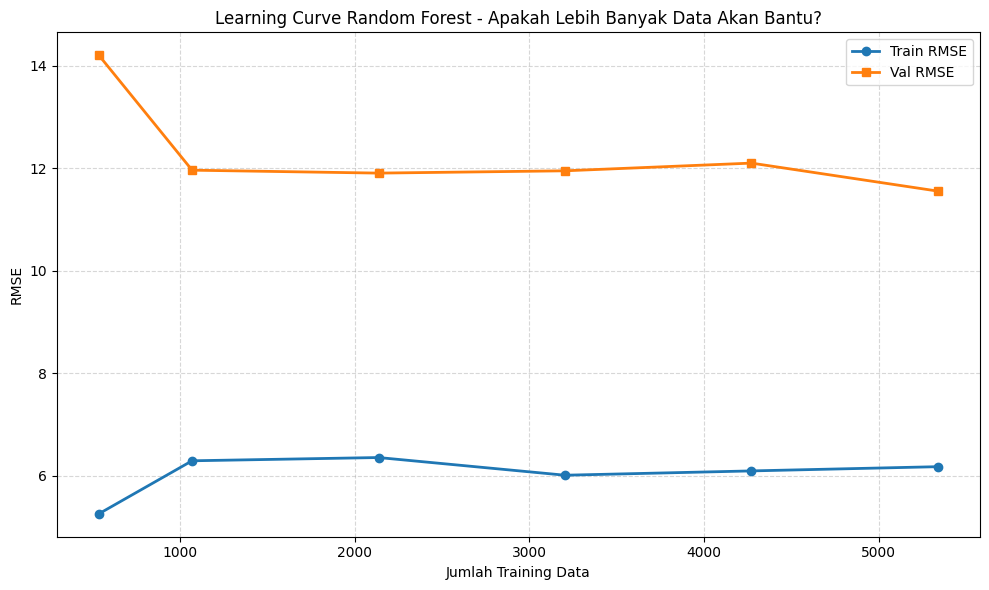


=== INTERPRETASI ===
-> val_RMSE masih TURUN (-0.547). Mungkin masih bisa improve dengan lebih banyak data.
Train RMSE akhir : 6.173
Val   RMSE akhir : 11.549
Gap                : 5.376 (gap besar = overfitting)


In [5]:
from sklearn.model_selection import learning_curve

fraksi = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
rmse_train, rmse_val = [], []

for f in fraksi:
    n_subset = int(len(X_tr) * f)
    if n_subset < 100: continue
    pipe_tmp = Pipeline([('pre', pre.__class__(transformers=pre.transformers)),
                          ('model', RandomForestRegressor(**PARAMS_RF_TERBAIK))])
    # Re-build pre to avoid fitted state
    pre_tmp = ColumnTransformer([
        ('num', SimpleImputer(strategy='median'), KOLOM_NUMERIK),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                          ('oh', OneHotEncoder(handle_unknown='ignore'))]), ['musim']),
    ])
    pipe_tmp = Pipeline([('pre', pre_tmp), ('model', RandomForestRegressor(**PARAMS_RF_TERBAIK))])
    pipe_tmp.fit(X_tr.iloc[:n_subset], y_tr.iloc[:n_subset])
    p_tr = pipe_tmp.predict(X_tr.iloc[:n_subset])
    p_va = pipe_tmp.predict(X_va)
    rmse_train.append(float(np.sqrt(mean_squared_error(y_tr.iloc[:n_subset], p_tr))))
    rmse_val.append(float(np.sqrt(mean_squared_error(y_va, p_va))))

n_used = [int(len(X_tr) * f) for f in fraksi]
df_lc = pd.DataFrame({'n_train': n_used, 'train_RMSE': rmse_train, 'val_RMSE': rmse_val})
df_lc.to_csv(DIR_OUT / 'learning_curve_rf.csv', index=False)

plt.figure(figsize=(10, 6))
plt.plot(df_lc['n_train'], df_lc['train_RMSE'], 'o-', label='Train RMSE', color='#1f77b4', linewidth=2)
plt.plot(df_lc['n_train'], df_lc['val_RMSE'],   's-', label='Val RMSE',   color='#ff7f0e', linewidth=2)
plt.xlabel('Jumlah Training Data'); plt.ylabel('RMSE')
plt.title('Learning Curve Random Forest - Apakah Lebih Banyak Data Akan Bantu?')
plt.legend(); plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout(); plt.savefig(DIR_OUT / 'learning_curve_rf.png', dpi=130); plt.show()

print('\n=== INTERPRETASI ===')
gap_akhir = df_lc.iloc[-1]['val_RMSE'] - df_lc.iloc[-2]['val_RMSE']
if abs(gap_akhir) < 0.1:
    print(f'-> val_RMSE PLATEAU di {df_lc.iloc[-1]["val_RMSE"]:.3f} (delta {gap_akhir:+.3f}). Data sudah cukup, tambah data TIDAK akan banyak bantu.')
elif gap_akhir < 0:
    print(f'-> val_RMSE masih TURUN ({gap_akhir:+.3f}). Mungkin masih bisa improve dengan lebih banyak data.')
else:
    print(f'-> val_RMSE naik ({gap_akhir:+.3f}) - tanda overfitting ringan.')

print(f'Train RMSE akhir : {df_lc.iloc[-1]["train_RMSE"]:.3f}')
print(f'Val   RMSE akhir : {df_lc.iloc[-1]["val_RMSE"]:.3f}')
print(f'Gap                : {df_lc.iloc[-1]["val_RMSE"] - df_lc.iloc[-1]["train_RMSE"]:.3f} (gap besar = overfitting)')

## 5. Analisis 2 - Permutation Importance

**Pertanyaan:** seberapa pentingnya tiap fitur **secara nyata** (model-agnostic)?

**Metode:** shuffle satu fitur, ukur penurunan performa. Penurunan besar = fitur penting. Lebih reliable daripada `feature_importances_` bawaan RF karena tidak bias ke fitur kontinyu dengan banyak unique values.

In [6]:
# Permutation importance di validation set
perm = permutation_importance(model_rf, X_va, y_va, n_repeats=10, random_state=RANDOM, n_jobs=-1, scoring='neg_root_mean_squared_error', verbose=1)

df_perm = pd.DataFrame({
    'fitur': X_va.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std,
}).sort_values('importance_mean', ascending=False).reset_index(drop=True)
df_perm['importance_mean'] = df_perm['importance_mean'].round(4)
df_perm['importance_std'] = df_perm['importance_std'].round(4)
df_perm.to_csv(DIR_OUT / 'permutation_importance_rf.csv', index=False)

plt.figure(figsize=(9, 8))
top = df_perm.head(20)
plt.barh(top['fitur'][::-1], top['importance_mean'][::-1],
         xerr=top['importance_std'][::-1], color='steelblue', alpha=0.85)
plt.xlabel('Permutation Importance (RMSE drop)')
plt.title('Top 20 Permutation Importance - Random Forest Terbaik')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout(); plt.savefig(DIR_OUT / 'permutation_importance_rf.png', dpi=130); plt.show()

display(df_perm.head(15))

TypeError: got an unexpected keyword argument 'verbose'

## 6. Analisis 3 - SHAP Analysis

**Pertanyaan:** bagaimana tiap fitur mempengaruhi prediksi individual?

**Metode:** SHAP (SHapley Additive exPlanations) memberikan kontribusi tiap fitur ke prediksi tiap baris. Summary plot menunjukkan importance + arah pengaruh.

In [ ]:
# SHAP perlu raw model, ekstrak dari pipeline
estimator = model_rf.named_steps['model']
X_te_transformed = model_rf.named_steps['pre'].transform(X_te)
# Get column names after transform
nama_cat = list(model_rf.named_steps['pre'].named_transformers_['cat'].named_steps['oh'].get_feature_names_out(['musim']))
nama_fitur_final = KOLOM_NUMERIK + nama_cat

# SHAP TreeExplainer (cepat untuk RF)
print('Menghitung SHAP values (mungkin 1-2 menit)...')
explainer = shap.TreeExplainer(estimator)

# Pakai subset 200 baris test untuk efisiensi
sample_idx = np.random.RandomState(RANDOM).choice(len(X_te_transformed), min(200, len(X_te_transformed)), replace=False)
X_sample = X_te_transformed[sample_idx]
shap_values = explainer.shap_values(X_sample)

# Summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, feature_names=nama_fitur_final, show=False, max_display=15)
plt.title('SHAP Summary - Top 15 Fitur (Pengaruh ke Prediksi PM2.5)', fontsize=12)
plt.tight_layout(); plt.savefig(DIR_OUT / 'shap_summary_rf.png', dpi=130, bbox_inches='tight'); plt.show()

# Bar plot mean |SHAP|
plt.figure(figsize=(9, 8))
shap.summary_plot(shap_values, X_sample, feature_names=nama_fitur_final, plot_type='bar', show=False, max_display=15)
plt.title('SHAP Mean |Importance| - Top 15 Fitur', fontsize=12)
plt.tight_layout(); plt.savefig(DIR_OUT / 'shap_bar_rf.png', dpi=130, bbox_inches='tight'); plt.show()

# Save SHAP values for top fitur
mean_abs_shap = np.abs(shap_values).mean(axis=0)
df_shap = pd.DataFrame({'fitur': nama_fitur_final, 'mean_abs_shap': mean_abs_shap}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
df_shap['mean_abs_shap'] = df_shap['mean_abs_shap'].round(4)
df_shap.to_csv(DIR_OUT / 'shap_importance_rf.csv', index=False)
display(df_shap.head(15))

## 7. Analisis 4 - PR Curve & ROC Curve untuk Klasifikasi PM2.5 > 100

**Pertanyaan:** seberapa baik prediksi RF kalau dipakai sebagai sistem peringatan dini "Tidak Sehat"?

**Metode:** treat prediksi PM2.5 sebagai skor klasifikasi (semakin tinggi = semakin mungkin "Tidak Sehat"). Plot Precision-Recall curve dan ROC curve. Hitung AUC.

In [ ]:
# Binary label: 1 jika aktual > 100 (Tidak Sehat), 0 selain itu
y_te_binary = (y_te > 100).astype(int)
skor_kontinyu = pred_te  # raw prediction sebagai skor

# PR Curve
prec, recall, thr_pr = precision_recall_curve(y_te_binary, skor_kontinyu)
ap = average_precision_score(y_te_binary, skor_kontinyu)

# ROC Curve
fpr, tpr, thr_roc = roc_curve(y_te_binary, skor_kontinyu)
roc_auc = auc(fpr, tpr)

# Baseline (proporsi positif untuk PR; 0.5 untuk ROC)
baseline_pr = y_te_binary.mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].plot(recall, prec, color='steelblue', linewidth=2, label=f'PR (AP = {ap:.3f})')
axes[0].axhline(baseline_pr, color='red', linestyle='--', label=f'Baseline = {baseline_pr:.3f} (proporsi positif)')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve - Klasifikasi "Tidak Sehat" (PM2.5>100)')
axes[0].legend(loc='best'); axes[0].grid(linestyle='--', alpha=0.5)
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1.05)

axes[1].plot(fpr, tpr, color='darkgreen', linewidth=2, label=f'ROC (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Klasifikasi "Tidak Sehat" (PM2.5>100)')
axes[1].legend(loc='best'); axes[1].grid(linestyle='--', alpha=0.5)
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1.05)

plt.tight_layout(); plt.savefig(DIR_OUT / 'pr_roc_curve_pm25_tinggi.png', dpi=130); plt.show()

# Cari threshold optimal (F1 maksimal pada PR curve)
f1_scores = 2 * prec * recall / (prec + recall + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thr_pr[best_idx] if best_idx < len(thr_pr) else thr_pr[-1]
print(f'\n=== HASIL KLASIFIKASI ===')
print(f'AP (Average Precision)    : {ap:.4f}')
print(f'AUC ROC                   : {roc_auc:.4f}')
print(f'Best F1                   : {f1_scores[best_idx]:.4f} (threshold prediksi = {best_threshold:.2f})')
print(f'Precision pada best F1    : {prec[best_idx]:.4f}')
print(f'Recall pada best F1       : {recall[best_idx]:.4f}')
print(f'Baseline (proporsi positif): {baseline_pr:.4f} ({int(y_te_binary.sum())} dari {len(y_te_binary)} test data)')

pd.DataFrame({
    'metrik': ['Average_Precision', 'AUC_ROC', 'Best_F1', 'Best_threshold', 'Precision_at_best_F1', 'Recall_at_best_F1', 'baseline_proporsi_positif'],
    'nilai':  [ap, roc_auc, float(f1_scores[best_idx]), float(best_threshold), float(prec[best_idx]), float(recall[best_idx]), baseline_pr],
}).to_csv(DIR_OUT / 'klasifikasi_pm25_tinggi_rf.csv', index=False)

## 8. Analisis 5 - Error Temporal per Stasiun

**Pertanyaan:** apakah error terkonsentrasi di stasiun tertentu pada periode tertentu?

**Metode:** group prediksi test set per (stasiun, minggu), hitung RMSE. Plot heatmap stasiun × waktu.

In [ ]:
# Bangun DataFrame prediksi
df_pred_test = pd.DataFrame({
    'tanggal': df.loc[m_te, 'tanggal'].values,
    'station': df.loc[m_te, 'station'].values,
    'aktual': y_te.values,
    'prediksi': pred_te,
})
df_pred_test['error'] = df_pred_test['aktual'] - df_pred_test['prediksi']
df_pred_test['abs_error'] = df_pred_test['error'].abs()
df_pred_test['minggu'] = pd.to_datetime(df_pred_test['tanggal']).dt.to_period('W').astype(str)

# RMSE per (stasiun, minggu)
rmse_st_wk = (df_pred_test.groupby(['station', 'minggu'])
              .apply(lambda x: float(np.sqrt(((x['error'])**2).mean())))
              .reset_index()
              .rename(columns={0: 'RMSE'}))
rmse_st_wk.to_csv(DIR_OUT / 'error_temporal_per_station.csv', index=False)

# Pivot untuk heatmap
pivot = rmse_st_wk.pivot(index='station', columns='minggu', values='RMSE')

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
sns.heatmap(pivot, cmap='RdYlGn_r', annot=False, ax=axes[0], cbar_kws={'label': 'RMSE'})
axes[0].set_title('Heatmap RMSE per Stasiun x Minggu (Test Set)')
axes[0].set_ylabel('Stasiun'); axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

# Boxplot error per stasiun
df_pred_test.boxplot(column='abs_error', by='station', ax=axes[1])
axes[1].set_title('Distribusi |error| per Stasiun')
axes[1].set_ylabel('|error| (ISPU PM2.5)'); axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
plt.suptitle('')  # remove auto-title
plt.tight_layout(); plt.savefig(DIR_OUT / 'error_temporal_per_station.png', dpi=130); plt.show()

# Stasiun dengan error tertinggi & terendah
ringkasan = (df_pred_test.groupby('station')['abs_error']
             .agg(['mean', 'median', 'std', 'max'])
             .round(2)
             .sort_values('mean', ascending=False))
ringkasan.to_csv(DIR_OUT / 'ringkasan_error_per_station.csv')
print('\n=== RINGKASAN ERROR PER STASIUN (test set) ===')
display(ringkasan)
print(f'\nStasiun dengan error terburuk : {ringkasan.index[0]} (mean |error| = {ringkasan["mean"].iloc[0]:.2f})')
print(f'Stasiun dengan error terbaik  : {ringkasan.index[-1]} (mean |error| = {ringkasan["mean"].iloc[-1]:.2f})')

## 9. Ringkasan & Kesimpulan Analisis Lanjutan

**1. Learning Curve** - apakah lebih banyak data akan bantu?
- Lihat `learning_curve_rf.csv` dan grafik. Jika val_RMSE PLATEAU di akhir, artinya data sudah cukup (information ceiling). Jika masih turun, ada potensi gain dari more data.

**2. Permutation Importance** - fitur yang benar-benar penting:
- File `permutation_importance_rf.csv`. Biasanya `pm25_lag_1` paling penting (autoregresif). Fitur cuaca yang muncul di top-10 = layak masuk laporan sebagai contributing factor.

**3. SHAP Analysis** - direksi pengaruh tiap fitur:
- `shap_summary_rf.png` menunjukkan **arah** pengaruh: titik merah di kanan = nilai tinggi menaikkan prediksi. Misal `humidity` titik merah di kiri = humidity tinggi MENURUNKAN prediksi PM2.5 (sesuai literatur wet deposition).

**4. PR / ROC Curve** - performa sebagai sistem alert:
- `pr_roc_curve_pm25_tinggi.png`. AUC ROC > 0.8 = good early warning. AP > baseline (~0.07) = lebih baik dari random.

**5. Error Temporal per Stasiun** - di mana model gagal:
- `error_temporal_per_station.png` heatmap. Stasiun dengan error mean tinggi = perlu perhatian khusus (mungkin pola PM2.5 unique). Periode dengan error tinggi = event yang model tidak antisipasi.

**File output (semua di `outputs/`):**
- `learning_curve_rf.csv` + `.png`
- `permutation_importance_rf.csv` + `.png`
- `shap_importance_rf.csv` + `shap_summary_rf.png` + `shap_bar_rf.png`
- `pr_roc_curve_pm25_tinggi.png` + `klasifikasi_pm25_tinggi_rf.csv`
- `error_temporal_per_station.csv` + `.png` + `ringkasan_error_per_station.csv`

Untuk laporan: 5 analisis ini bisa di-cite sebagai validasi metodologi (learning curve membuktikan data sufficient, permutation importance + SHAP membuktikan fitur cuaca contributing, PR/ROC membuktikan model usable sebagai alert, error temporal mengidentifikasi limitations spesifik per stasiun).